# OLA - Ensemble Learning (Case Study)


**Problem Definition:**

Ola is facing a high churn rate among its drivers, which is a major challenge for its operations. Drivers can easily leave the platform or switch to competitors like Uber, primarily due to fluctuating rates and other factors. This high turnover is costly and affects both operational efficiency and company morale. The primary issue is that acquiring new drivers is significantly more expensive than retaining existing ones, leading to financial strain.

**Objective:**

The objective of the problem is to predict driver attrition—whether a driver is likely to leave Ola in the near future—using various attributes such as:

* Demographic details (e.g., city, age, gender)
* Tenure information (e.g., joining date, last working date)
* Performance metrics (e.g., quarterly rating, monthly business, income, grade)

By predicting attrition, Ola can take preemptive measures to retain drivers and reduce the costly process of constantly acquiring new ones.

**Why Predicting Driver Attrition is Important?**

* **Cost Efficiency:** Reducing churn saves money on recruitment, as retaining drivers is cheaper than acquiring new ones, improving profitability.

* **Impact on Morale:** Frequent driver exits can hurt team morale and the organization's culture. Preventing churn enhances stability and engagement.

* **Business Continuity:** A consistent pool of drivers ensures smoother operations and reduces service disruptions, which is crucial for customer satisfaction.

* **Strategic Planning:** Insights from attrition predictions enable targeted retention strategies, improving driver satisfaction and long-term company stability.

**Column Profiling:**

* **MMMM-YY :** Reporting Date (Monthly).
* **Driver_ID :** Unique id for drivers.
* **Age :** Age of the driver.
* **Gender :** Gender of the driver – Male : 0, Female: 1
* **City :** City code representing the city the driver operates in.
* **Education_Level :** Education level – 0 for 10+ ,1 for 12+ ,2 for graduate.
* **Income :** Monthly average Income of the driver.
* **Date Of Joining :** Joining date for the driver.
* **LastWorkingDate :** Last date of working for the driver.
* **Joining Designation :** Designation of the driver at the time of joining.
* **Grade :** Grade of the driver at the time of reporting.
* **Total Business Value :** The total business value acquired by the driver in a month (negative business indicates cancellation/refund or car EMI adjustments).
* **Quarterly Rating :** Quarterly rating of the driver: 1,2,3,4,5 (higher is better).

In [1]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statistics

import warnings
warnings.simplefilter('ignore')

In [2]:
# get the dataset (csv file) from the link

!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv

--2024-08-24 14:54:01--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 3.167.84.9, 3.167.84.196, 3.167.84.148, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|3.167.84.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1127673 (1.1M) [text/plain]
Saving to: ‘ola_driver_scaler.csv’

ola_driver_scaler.c 100%[===================>]   1.08M  --.-KB/s    in 0.08s   

2024-08-24 14:54:01 (14.0 MB/s) - ‘ola_driver_scaler.csv’ saved [1127673/1127673]



In [3]:
# read the csv file

df=pd.read_csv("ola_driver_scaler.csv")

# **Exploratory Data Analysis**

In [4]:
# shape of the data

df.shape

(19104, 14)

**Insights:** Dataset has 19104 rows and 14 columns.


In [5]:
df.head(10)

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
5,5,12/01/19,4,43.0,0.0,C13,2,65603,12/07/19,NaN,2,2,0,1
6,6,01/01/20,4,43.0,0.0,C13,2,65603,12/07/19,NaN,2,2,0,1
7,7,02/01/20,4,43.0,0.0,C13,2,65603,12/07/19,NaN,2,2,0,1
8,8,03/01/20,4,43.0,0.0,C13,2,65603,12/07/19,NaN,2,2,350000,1
9,9,04/01/20,4,43.0,0.0,C13,2,65603,12/07/19,27/04/20,2,2,0,1


In [6]:
df.columns

Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

In [7]:
# Basic Information about the Dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


In [8]:
# Removing the unwanted column 'Unnamed: 0'

df.drop("Unnamed: 0", axis = 1, inplace = True)

In [9]:
# Convert 'MMM-YY', 'Dateofjoining' & 'LastWorkingDate' to datetime

df['MMM-YY'] = pd.to_datetime(df['MMM-YY'])
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'])
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'])

In [10]:
# Convert non-null values of 'Age' & 'Gender' to int64

df['Age'] = pd.to_numeric(df['Age'], errors='coerce').astype('Int64')
df['Gender'] = pd.to_numeric(df['Gender'], errors='coerce').astype('Int64')

In [11]:
df.head()

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,2019-01-01,1,28,0,C23,2,57387,2018-12-24,NaT,1,1,2381060,2
1,2019-02-01,1,28,0,C23,2,57387,2018-12-24,NaT,1,1,-665480,2
2,2019-03-01,1,28,0,C23,2,57387,2018-12-24,2019-03-11,1,1,0,2
3,2020-11-01,2,31,0,C7,2,67016,2020-11-06,NaT,2,2,0,1
4,2020-12-01,2,31,0,C7,2,67016,2020-11-06,NaT,2,2,0,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MMM-YY                19104 non-null  datetime64[ns]
 1   Driver_ID             19104 non-null  int64         
 2   Age                   19043 non-null  Int64         
 3   Gender                19052 non-null  Int64         
 4   City                  19104 non-null  object        
 5   Education_Level       19104 non-null  int64         
 6   Income                19104 non-null  int64         
 7   Dateofjoining         19104 non-null  datetime64[ns]
 8   LastWorkingDate       1616 non-null   datetime64[ns]
 9   Joining Designation   19104 non-null  int64         
 10  Grade                 19104 non-null  int64         
 11  Total Business Value  19104 non-null  int64         
 12  Quarterly Rating      19104 non-null  int64         
dtypes: Int64(2), dat

In [13]:
df.isna().sum()

,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488
Joining Designation,0


**Insights:**

* There are missing values found in `Age` and `Gender`.
* `LastWorkingDate` feature contains missing values which indicates the driver has not left the company yet.

In [14]:
df.nunique()

,0
MMM-YY,24
Driver_ID,2381
Age,36
Gender,2
City,29
Education_Level,3
Income,2383
Dateofjoining,869
LastWorkingDate,493
Joining Designation,5


In [15]:
# Duplicate value check

df.duplicated().sum()

0

**Insights:** No duplicate rows are present in the dataframe.

# **Feature Engineering**

In [16]:
df.columns

Index(['MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level',
       'Income', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation',
       'Grade', 'Total Business Value', 'Quarterly Rating'],
      dtype='object')

## KNN imputation

In [17]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Selecting numerical features and creating a Datafram with only numerical features
num_vars = ['Age', 'Gender', 'Income', 'Grade', 'Total Business Value', 'Quarterly Rating']
df_new = df[num_vars].copy()

# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[num_vars])

# Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(df_scaled)

# Assign the imputed values back to the DataFrame
df_new[num_vars] = scaler.inverse_transform(df_imputed)

In [18]:
df_new.isna().sum()

,0
Age,0
Gender,0
Income,0
Grade,0
Total Business Value,0
Quarterly Rating,0


In [19]:
df_new.nunique()

,0
Age,68
Gender,8
Income,2383
Grade,5
Total Business Value,10181
Quarterly Rating,4


**Note:** The original DataFrame has 36 unique ages and 2 genders. However, after applying KNN imputation, there are now 68 unique ages and 8 unique gender values, which is incorrect.

In [20]:
miss_df = df.groupby('Driver_ID').agg({
    'Gender': 'last',
    'Age': 'max'
}).reset_index()

In [21]:
miss_df.isna().sum()

,0
Driver_ID,0
Gender,0
Age,0


**Note:** This ensures that each `Driver_ID` has both `Gender` and `Age` values present in at least one row of the DataFrame, even if some rows have missing values. So, we can handle missing values while aggregating the dataset.

## Aggregating the Dataset

In [22]:
# Aggregating on 'Driver_ID' might be essential to identify consistent behaviors or patterns.

# Let's analyse the data for the driver having Driver_ID = 21.
df[df["Driver_ID"]==21]

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
74,2019-01-01,21,33,1,C29,1,22755,2018-05-12,NaT,1,1,948560,4
75,2019-02-01,21,33,1,C29,1,22755,2018-05-12,NaT,1,1,551740,4
76,2019-03-01,21,33,1,C29,1,22755,2018-05-12,NaT,1,1,3295370,4
77,2019-04-01,21,33,1,C29,1,22755,2018-05-12,NaT,1,1,0,2
78,2019-05-01,21,33,1,C29,1,22755,2018-05-12,NaT,1,1,116350,2
79,2019-06-01,21,33,1,C29,1,22755,2018-05-12,NaT,1,1,533260,2
80,2019-07-01,21,33,1,C29,1,22755,2018-05-12,NaT,1,1,150450,2
81,2019-08-01,21,33,1,C29,1,22755,2018-05-12,NaT,1,1,0,2
82,2019-09-01,21,33,1,C29,1,22755,2018-05-12,NaT,1,1,520980,2
83,2019-10-01,21,33,1,C29,1,22755,2018-05-12,NaT,1,1,150600,2


In [23]:
# Restructuring the data by aggregating on 'driverid'.

function = {'MMM-YY':'count',
             'Age':'max',
             'Gender':'last',
             'City':'last',
             'Education_Level':'last',
             'Dateofjoining':'first',
             'LastWorkingDate':'last',
             'Grade':'last',
             'Total Business Value':'sum',
             'Income':['first', 'last', 'sum'],
             'Joining Designation':'last',
             'Grade':'last',
             'Quarterly Rating':['first', 'last']
             }

agg_df = df.groupby(["Driver_ID"]).aggregate(function).reset_index()

In [24]:
agg_df.head()

Driver_ID MMM-YY Age Gender City Education_Level Dateofjoining  \
             count max   last last            last         first   
0         1      3  28      0  C23               2    2018-12-24   
1         2      2  31      0   C7               2    2020-11-06   
2         4      5  43      0  C13               2    2019-12-07   
3         5      3  29      0   C9               0    2019-01-09   
4         6      5  31      1  C11               1    2020-07-31   

  LastWorkingDate Grade Total Business Value Income                 \
             last  last                  sum  first   last     sum   
0      2019-03-11     1              1715580  57387  57387  172161   
1             NaT     2                    0  67016  67016  134032   
2      2020-04-27     2               350000  65603  65603  328015   
3      2019-03-07     1               120360  46368  46368  139104   
4             NaT     3              1265000  78728  78728  393640   

  Joining Designation Quarterly Rating       
                 last            first last  
0                   1                2    2  
1                   2                1    1  
2                   2                1    1  
3                   1                1    1  
4                   3                1    2

Create a column which tells whether the quarterly rating has increased for that driver - for those whose quarterly rating has increased we assign the value 1.

In [25]:
# Create a new column 'Rating_Increased' based on whether the quarterly rating has increased

agg_df['Rating_Increased'] = (agg_df['Quarterly Rating']['last'] > agg_df['Quarterly Rating']['first']).astype(int)

In [26]:
# Drop the original 'Quarterly Rating first' column

agg_df.drop(columns=[('Quarterly Rating', 'first')], inplace=True)

Create a column which tells whether the monthly income has increased for that driver - for those whose monthly income has increased we assign the value 1.

In [27]:
# Create a new column 'Raise' based on whether the income has increased

agg_df['Raise'] = (agg_df['Income']['last'] > agg_df['Income']['first']).astype(int)

In [28]:
# Drop the original 'Income last' and 'Income last' columns

agg_df.drop(columns=[('Income', 'first'),('Income', 'last')], inplace=True)

In [29]:
agg_df.head()

,Driver_ID,MMM-YY,Age,Gender,City,Education_Level,Dateofjoining,LastWorkingDate,Grade,Total Business Value,Income,Joining Designation,Quarterly Rating,Rating_Increased,Raise
,,count,max,last,last,last,first,last,last,sum,sum,last,last,,
0,1,3,28,0,C23,2,2018-12-24,2019-03-11,1,1715580,172161,1,2,0,0
1,2,2,31,0,C7,2,2020-11-06,NaT,2,0,134032,2,1,0,0
2,4,5,43,0,C13,2,2019-12-07,2020-04-27,2,350000,328015,2,1,0,0
3,5,3,29,0,C9,0,2019-01-09,2019-03-07,1,120360,139104,1,1,0,0
4,6,5,31,1,C11,1,2020-07-31,NaT,3,1265000,393640,3,2,1,0


In [30]:
# Rename columns to desired names

agg_df.columns = ['Driver_ID', 'Reportings', 'Age', 'Gender', 'City', 'Education_Level', 'Dateofjoining',
                  'LastWorkingDate', 'Grade', 'Total_Business_Value', 'Income',
                  'Joining_Designation', 'Last_Quarterly_Rating', 'Rating_Increased', 'Raise']

In [31]:
agg_df.head()

,Driver_ID,Reportings,Age,Gender,City,Education_Level,Dateofjoining,LastWorkingDate,Grade,Total_Business_Value,Income,Joining_Designation,Last_Quarterly_Rating,Rating_Increased,Raise
0,1,3,28,0,C23,2,2018-12-24,2019-03-11,1,1715580,172161,1,2,0,0
1,2,2,31,0,C7,2,2020-11-06,NaT,2,0,134032,2,1,0,0
2,4,5,43,0,C13,2,2019-12-07,2020-04-27,2,350000,328015,2,1,0,0
3,5,3,29,0,C9,0,2019-01-09,2019-03-07,1,120360,139104,1,1,0,0
4,6,5,31,1,C11,1,2020-07-31,NaT,3,1265000,393640,3,2,1,0


## Target variable creation

Create a column called target which tells whether the driver has left the company - driver whose last working day is present will have the value 1.

In [32]:
# Create a column called 'target' which tells whether the driver has left the company.

agg_df['target'] = agg_df['LastWorkingDate'].apply(lambda x: 0 if pd.isna(x) else 1)

In [33]:
agg_df[['LastWorkingDate','target']].head()

,LastWorkingDate,target
0,2019-03-11,1
1,NaT,0
2,2020-04-27,1
3,2019-03-07,1
4,NaT,0


In [34]:
# Extract month and year for joining date

agg_df['Month'] = agg_df['Dateofjoining'].dt.month
agg_df['Year'] = agg_df['Dateofjoining'].dt.year

In [35]:
# Removing columns 'Dateofjoining' (month and year already extracted) and 'LastWorkingDate' (target column already created)

agg_df.drop(columns = ['Dateofjoining','LastWorkingDate'], axis = 1, inplace = True)

In [36]:
agg_df.head()

,Driver_ID,Reportings,Age,Gender,City,Education_Level,Grade,Total_Business_Value,Income,Joining_Designation,Last_Quarterly_Rating,Rating_Increased,Raise,target,Month,Year
0,1,3,28,0,C23,2,1,1715580,172161,1,2,0,0,1,12,2018
1,2,2,31,0,C7,2,2,0,134032,2,1,0,0,0,11,2020
2,4,5,43,0,C13,2,2,350000,328015,2,1,0,0,1,12,2019
3,5,3,29,0,C9,0,1,120360,139104,1,1,0,0,1,1,2019
4,6,5,31,1,C11,1,3,1265000,393640,3,2,1,0,0,7,2020


In [37]:
agg_df.shape

(2381, 16)

**Insights:** The aggregated dataframe has 2381 rows and 16 columns.

In [38]:
agg_df.columns

Index(['Driver_ID', 'Reportings', 'Age', 'Gender', 'City', 'Education_Level',
       'Grade', 'Total_Business_Value', 'Income', 'Joining_Designation',
       'Last_Quarterly_Rating', 'Rating_Increased', 'Raise', 'target', 'Month',
       'Year'],
      dtype='object')

In [39]:
agg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Driver_ID              2381 non-null   int64 
 1   Reportings             2381 non-null   int64 
 2   Age                    2381 non-null   Int64 
 3   Gender                 2381 non-null   Int64 
 4   City                   2381 non-null   object
 5   Education_Level        2381 non-null   int64 
 6   Grade                  2381 non-null   int64 
 7   Total_Business_Value   2381 non-null   int64 
 8   Income                 2381 non-null   int64 
 9   Joining_Designation    2381 non-null   int64 
 10  Last_Quarterly_Rating  2381 non-null   int64 
 11  Rating_Increased       2381 non-null   int64 
 12  Raise                  2381 non-null   int64 
 13  target                 2381 non-null   int64 
 14  Month                  2381 non-null   int32 
 15  Year                 

In [40]:
agg_df.isna().sum()

,0
Driver_ID,0
Reportings,0
Age,0
Gender,0
City,0
Education_Level,0
Grade,0
Total_Business_Value,0
Income,0
Joining_Designation,0


**Insights:** No null values are detected in the aggegrated dataframe.

In [41]:
# Statistical summary

agg_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Driver_ID,2381.0,1397.559009,806.161628,1.0,695.0,1400.0,2100.0,2788.0
Reportings,2381.0,8.02352,6.78359,1.0,3.0,5.0,10.0,24.0
Age,2381.0,33.663167,5.983375,21.0,29.0,33.0,37.0,58.0
Gender,2381.0,0.410332,0.491997,0.0,0.0,0.0,1.0,1.0
Education_Level,2381.0,1.00756,0.81629,0.0,0.0,1.0,2.0,2.0
Grade,2381.0,2.096598,0.941522,1.0,1.0,2.0,3.0,5.0
Total_Business_Value,2381.0,4586741.822764,9127115.313446,-1385530.0,0.0,817680.0,4173650.0,95331060.0
Income,2381.0,526760.305754,623163.278373,10883.0,139895.0,292980.0,651456.0,4522032.0
Joining_Designation,2381.0,1.820244,0.841433,1.0,1.0,2.0,2.0,5.0
Last_Quarterly_Rating,2381.0,1.427971,0.809839,1.0,1.0,1.0,2.0,4.0


In [42]:
agg_df.describe(include = 'object')

,City
count,2381
unique,29
top,C20
freq,152


**Insights:**

*  There are total of 2831 different drivers data.
*  Age of drivers range from 21 years to 58 years.
*  75% drivers monthly income is <= 651456.
*  75% drivers acquired 4173650 as total business values.
*  Majority of drivers are coming from C20 city.

## Data Visualization

### Univariate analysis

In [43]:
# Count of unique Driver IDs

agg_df['Driver_ID'].nunique()

2381

In [44]:
print('First joining date: ',df['Dateofjoining'].min())
print('Last joining date: ',df['Dateofjoining'].max())

First joining date:  2013-04-01 00:00:00
Last joining date:  2020-12-28 00:00:00


In [45]:
print('First reporting date: ',df['MMM-YY'].min())
print('Last reporting date: ',df['MMM-YY'].max())

First reporting date:  2019-01-01 00:00:00
Last reporting date:  2020-12-01 00:00:00


**Insights:** The data represents the reporting of the drivers from Jan 2019 to Dec 2020.

In [46]:
agg_df["target"].value_counts()

,count
target,
1,1616
0,765


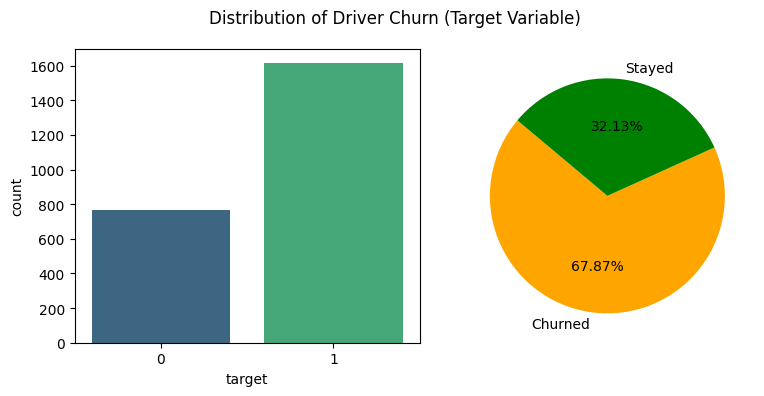

In [47]:
plt.figure(figsize=(8, 4))

# Create a bar plot
plt.subplot(1, 2, 1)
sns.countplot(x=agg_df['target'], palette='viridis')

# Create a pie chart
plt.subplot(1, 2, 2)
plt.pie(agg_df['target'].value_counts(), labels=['Churned','Stayed'], autopct='%1.2f%%', startangle=140, colors=['orange', 'green'])

plt.suptitle('Distribution of Driver Churn (Target Variable)', fontsize=12)
plt.tight_layout()
plt.show()

**Insights:**

* Class 1 (68%) of the drivers churned.  
* Class 0 (32%) of the drivers have not churned.

**Note:** Data is imbalanced

In [48]:
agg_df["Gender"].value_counts()

,count
Gender,
0,1404
1,977


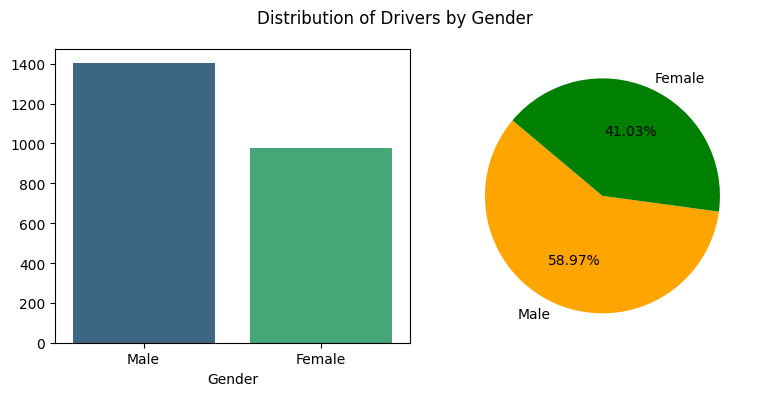

In [49]:
# Map 0 to 'Male' and 1 to 'Female'
gender_mapped = agg_df['Gender'].map({0: 'Male', 1: 'Female'})

# Calculate the distribution of gender
gender_counts = gender_mapped.value_counts()

plt.figure(figsize=(8, 4))

# Create a bar plot
plt.subplot(1, 2, 1)
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='viridis')

# Create a pie chart
plt.subplot(1, 2, 2)
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.2f%%', startangle=140, colors=['orange', 'green'])

plt.suptitle('Distribution of Drivers by Gender', fontsize=12)
plt.tight_layout()
plt.show()

**Insights:**

*  59% of the Drivers are male.
*  41% of the Drivers are female.

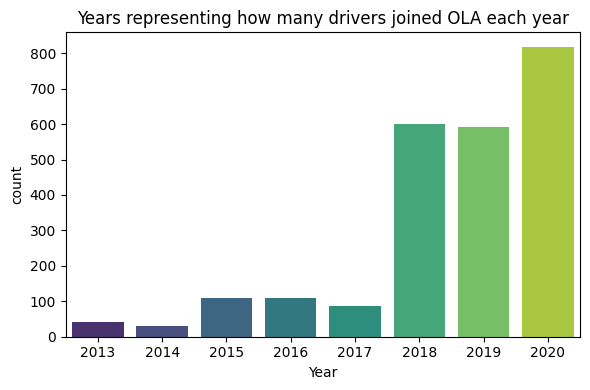

In [50]:
# Plotting the count of drivers joining each year

fig = plt.figure(figsize=(6,4))
sns.countplot(x=agg_df.Year,palette='viridis')
plt.title('Years representing how many drivers joined OLA each year', fontsize=12)
plt.tight_layout()
plt.show()

**Insights:** Joining of Drivers receives a boost of about 500% after 2017.

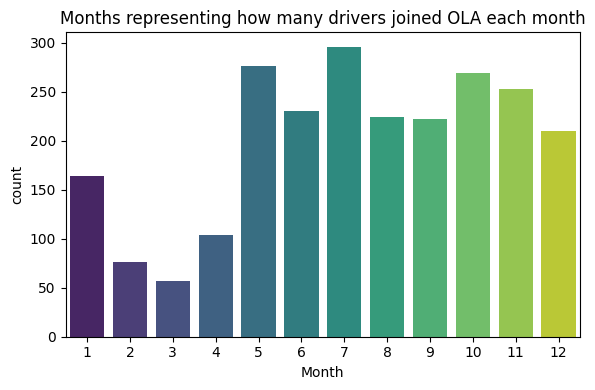

In [51]:
# Plotting the count of drivers joining each month

fig = plt.figure(figsize=(6,4))
sns.countplot(x=agg_df.Month,palette='viridis')
plt.title('Months representing how many drivers joined OLA each month', fontsize=12)
plt.tight_layout()
plt.show()

**Insights:**

*  July received the maximum number of drivers in 8 years.
*  February and March receives the least number of Drivers joining OLA.

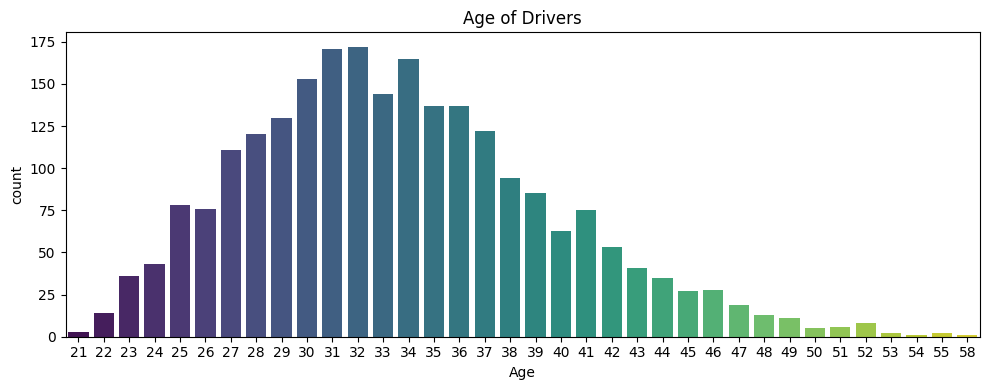

In [52]:
# Plotting the count of drivers by age

plt.figure(figsize=(10,4))
sns.countplot(x=agg_df.Age,palette='viridis')
plt.title('Age of Drivers',fontsize=12)
plt.tight_layout()
plt.show()

**Insights:** Between 21 years (min age) to 58 (max age) years of age, maximum number of drivers are 32 years old.

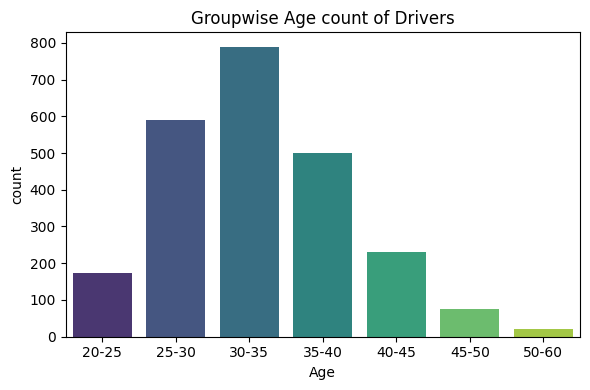

In [53]:
# Plotting the count of drivers in each age group

plt.figure(figsize=(6,4))
age_bins = pd.cut(agg_df.Age,bins=[20,25,30,35,40,45,50,60],labels=['20-25','25-30','30-35','35-40','40-45','45-50','50-60'])
sns.countplot(x=age_bins,palette='viridis')
plt.title('Groupwise Age count of Drivers',fontsize=12)
plt.tight_layout()
plt.show()

**Insights:** The age group between 30-35 years of age receives the maximum number of drivers.

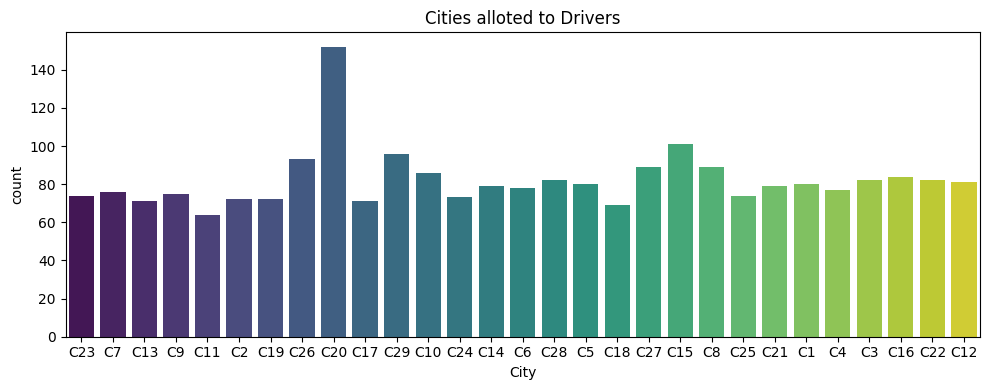

In [54]:
# Plotting the distribution of drivers across different cities

plt.figure(figsize=(10,4))
sns.countplot(x=agg_df.City,palette='viridis')
plt.title('Cities alloted to Drivers', fontsize=12)
plt.tight_layout()
plt.show()

**Insights:** Maximum number of drivers are allotted to City 20.

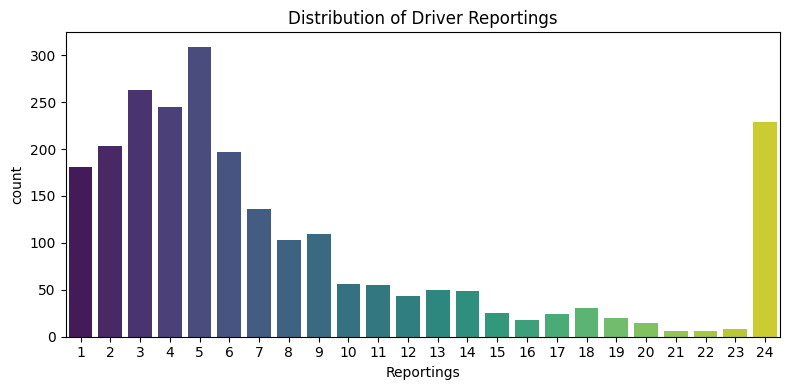

In [55]:
# Plotting the count of drivers by the number of months worked

plt.figure(figsize=(8,4))
sns.countplot(x=agg_df.Reportings,palette='viridis')
plt.title('Distribution of Driver Reportings', fontsize=12)
plt.tight_layout()
plt.show()

**Insights:**

*  The majority of drivers work between 2 to 6 months, with a peak at 5 months.
*  Drivers with 24 months tenure are still active, reflecting strong long-term engagement within the company.

In [56]:
columns = ['Grade','Joining_Designation','Education_Level','Last_Quarterly_Rating','Raise','Rating_Increased']

for col in columns:
  print(agg_df[col].value_counts(normalize=True) * 100)
  print("----------------------------------------------------------------------------")


Grade
2    35.909282
1    31.121378
3    26.165477
4     5.795884
5     1.007980
Name: proportion, dtype: float64
----------------------------------------------------------------------------
Joining_Designation
1    43.091138
2    34.229315
3    20.705586
4     1.511970
5     0.461991
Name: proportion, dtype: float64
----------------------------------------------------------------------------
Education_Level
2    33.683326
1    33.389332
0    32.927341
Name: proportion, dtype: float64
----------------------------------------------------------------------------
Last_Quarterly_Rating
1    73.246535
2    15.203696
3     7.055859
4     4.493910
Name: proportion, dtype: float64
----------------------------------------------------------------------------
Raise
0    98.194036
1     1.805964
Name: proportion, dtype: float64
----------------------------------------------------------------------------
Rating_Increased
0    84.964301
1    15.035699
Name: proportion, dtype: float64
---------------

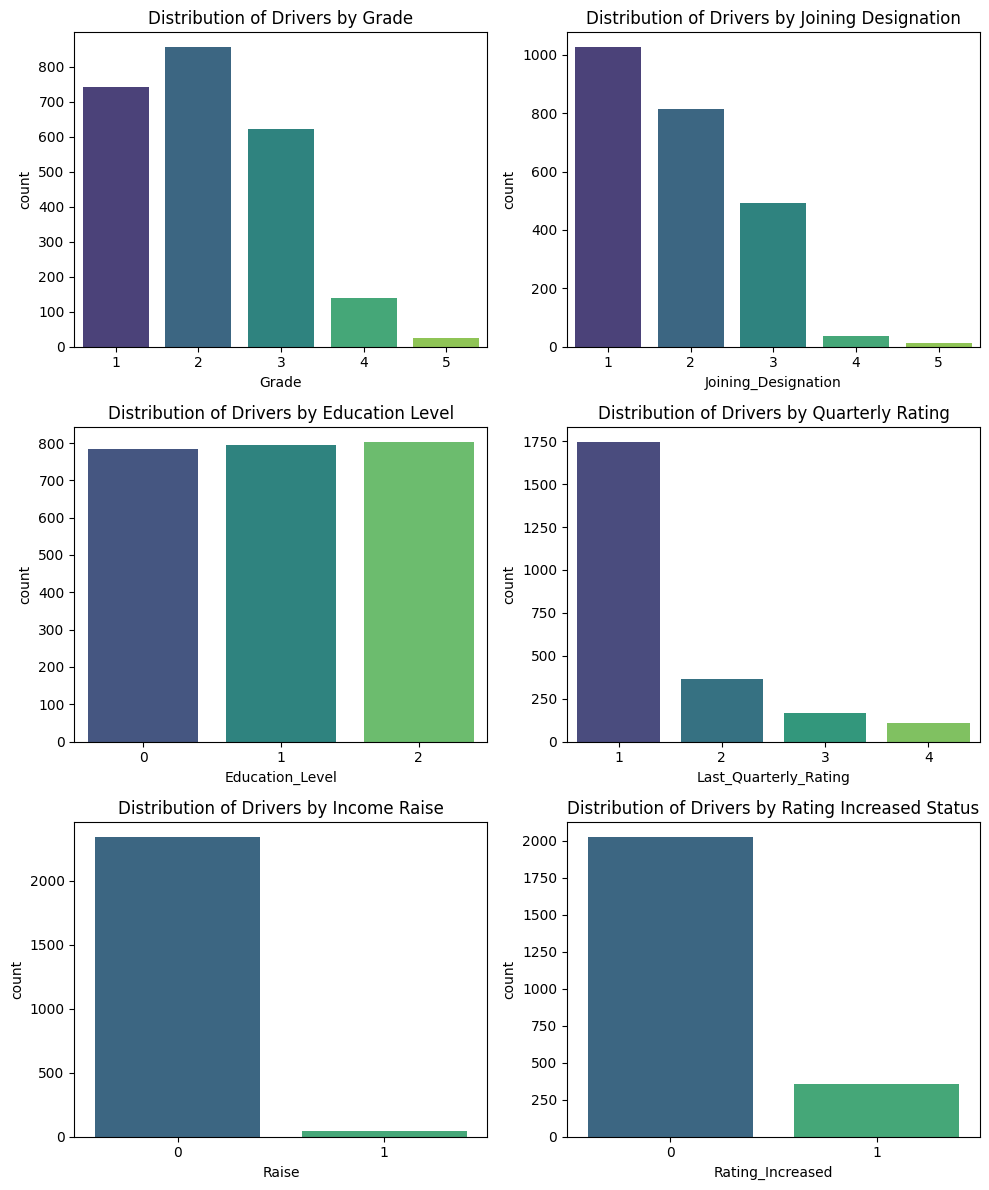

In [57]:
plt.figure(figsize=(10,12))

# Plot 1
plt.subplot(3, 2, 1)
sns.countplot(x=agg_df['Grade'], palette='viridis')
plt.title('Distribution of Drivers by Grade', fontsize=12)

# Plot 2
plt.subplot(3, 2, 2)
sns.countplot(x=agg_df['Joining_Designation'], palette='viridis')
plt.title('Distribution of Drivers by Joining Designation', fontsize=12)

# Plot 3
plt.subplot(3, 2, 3)
sns.countplot(x=agg_df['Education_Level'], palette='viridis')
plt.title('Distribution of Drivers by Education Level', fontsize=12)

# Plot 4
plt.subplot(3, 2, 4)
sns.countplot(x=agg_df['Last_Quarterly_Rating'], palette='viridis')
plt.title('Distribution of Drivers by Quarterly Rating', fontsize=12)

# Plot 5
plt.subplot(3, 2, 5)
sns.countplot(x=agg_df['Raise'], palette='viridis')
plt.title('Distribution of Drivers by Income Raise', fontsize=12)

# Plot 6
plt.subplot(3, 2, 6)
sns.countplot(x=agg_df['Rating_Increased'], palette='viridis')
plt.title('Distribution of Drivers by Rating Increased Status', fontsize=12)

plt.tight_layout()
plt.show()

**Insights:**

*  Grade: A majority of drivers are in grades 1 and 2, with few in higher grades like 4 and 5.
*  Joining Designation: Most drivers joined at Designation 1, with fewer drivers at Designations 4 and 5.
*  Education Level: Education levels show nearly equal distribution with slight variations, suggesting a balanced representation across categories.
*  Last Quarterly Rating: The majority of drivers (73%) received the lowest quarterly rating, with fewer drivers achieving higher ratings.
*  Raise: Almost all drivers did not receive a raise, with only a small fraction (1.8%) getting one.
*  Rating Increased: Only 15% of drivers rating has been increased on quarterly.

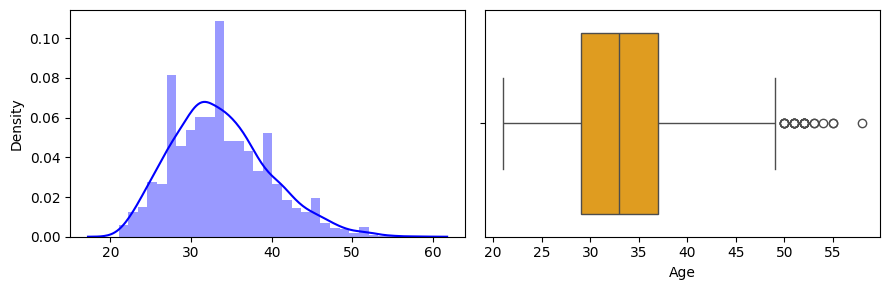

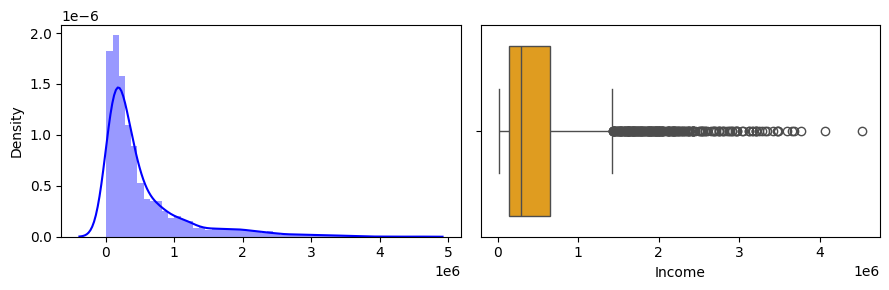

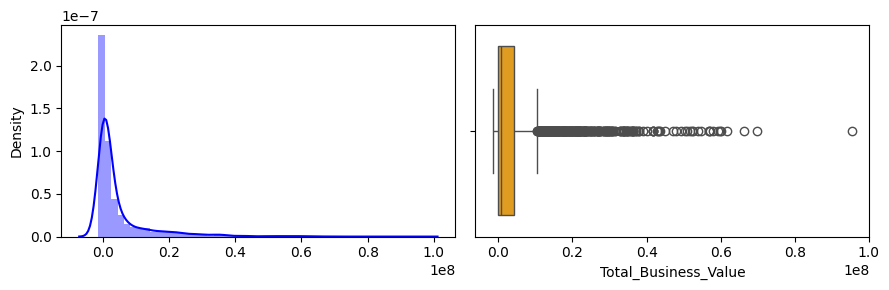

In [58]:
columns = ['Age','Income','Total_Business_Value']

for i in columns:
    plt.figure(figsize=(9,3))

    plt.subplot(1,2,1)
    sns.distplot(x=agg_df[i],color='blue')

    plt.subplot(1,2,2)
    sns.boxplot(x=agg_df[i],color='orange')

    plt.tight_layout()
    plt.show()

**Insights:**

*  Age: The distribution of age is slightly skewed on right which might indicate the outliers in the data.
*  Income: The distribution of monthly income is skewed on right which indicate the presence of outliers in the data.
*  Total Business Value: The distribution of total business value is highly skewed on right which indicate the presence of outliers in the data.

### Bivariate  and multivariate

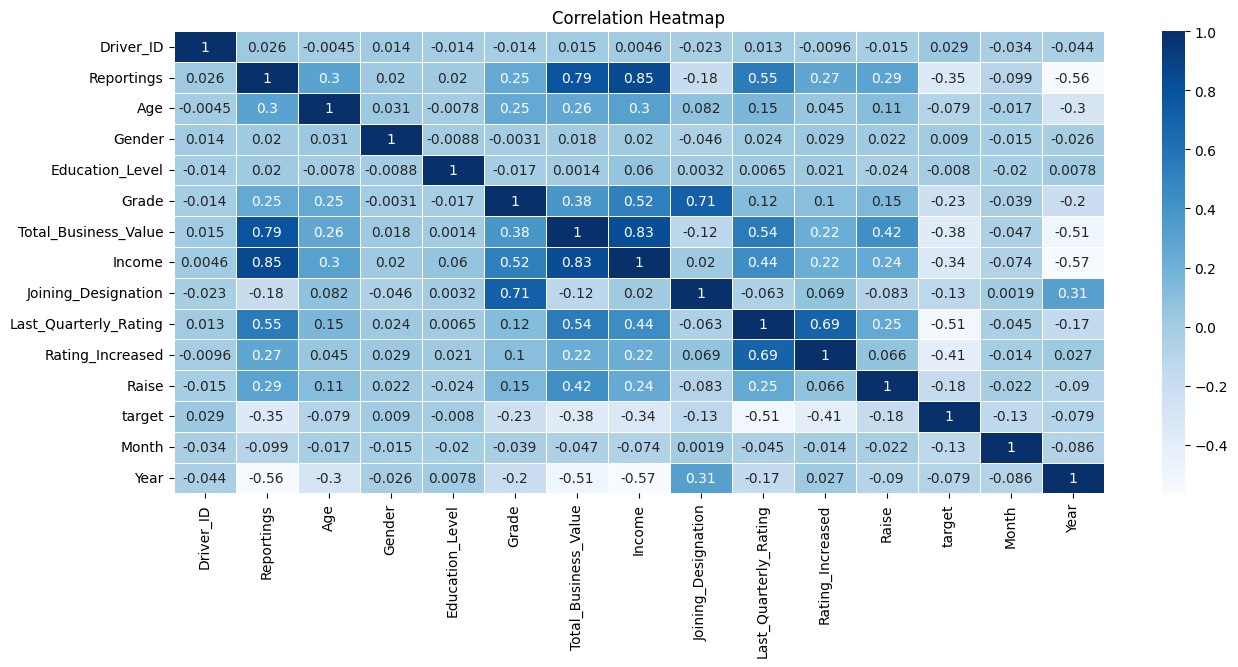

In [59]:
# Create a heatmap for the correlation matrix

plt.figure(figsize=(15,6))
sns.heatmap(agg_df.corr(numeric_only=True), annot=True, cmap='Blues',edgecolors='black',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Insights:**

*  Reportings strongly correlate with Income (0.85) and Total Business Value (0.79).
*  Total Business Value is strongly correlate with Income (0.83).
*  Grade highly correlates with Joining Designation (0.71) and has significant correlation with Income (0.52) and Total Business Value (0.38).
*  Last Quarterly Rating positively correlates with Reportings (0.55), Total Business Value (0.54) and Income (0.44).
*  Raise shows moderate correlation with Total Business Value (0.42), Reportings (0.29), Income (0.24) and Quarterly Rating (0.25).
*  Age shows moderate correlation with Reportings (0.3) and Income (0.3).
*  Target (churn) negatively correlates with Quarterly Rating (-0.51), Reportings (-0.35) and Income (-0.34).


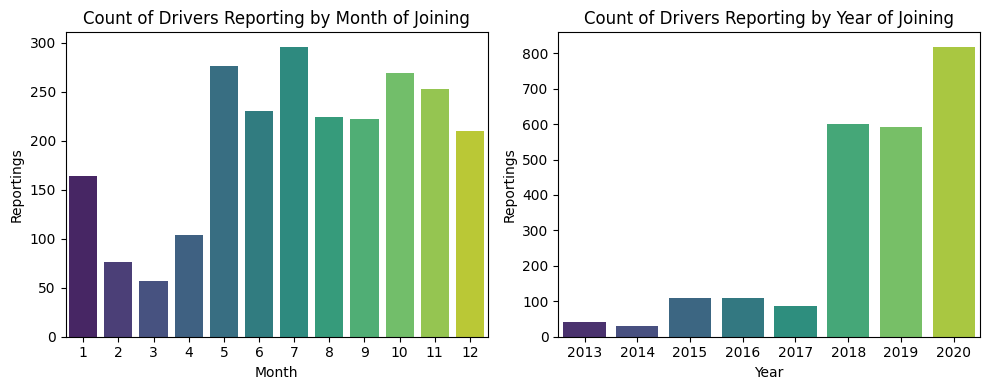

In [60]:
plt.figure(figsize=(10, 4))

# Plot 1: Count of Drivers Reporting by Month of Joining
plt.subplot(1, 2, 1)
grouped_months = agg_df.groupby(['Month'])['Reportings'].count().reset_index()
sns.barplot(data=grouped_months, x='Month', y='Reportings', palette='viridis')
plt.title('Count of Drivers Reporting by Month of Joining', fontsize=12)

# Plot 2: Count of Drivers Reporting by Year of Joining
plt.subplot(1, 2, 2)
grouped_years = agg_df.groupby(['Year'])['Reportings'].count().reset_index()
sns.barplot(data=grouped_years, x='Year', y='Reportings', palette='viridis')
plt.title('Count of Drivers Reporting by Year of Joining', fontsize=12)

plt.tight_layout()
plt.show()

**Insights:**

*  Drivers who joined after May have been reporting more actively.
*  Drivers who joined in 2018, 2019, and 2020 have shown the highest reporting activity.

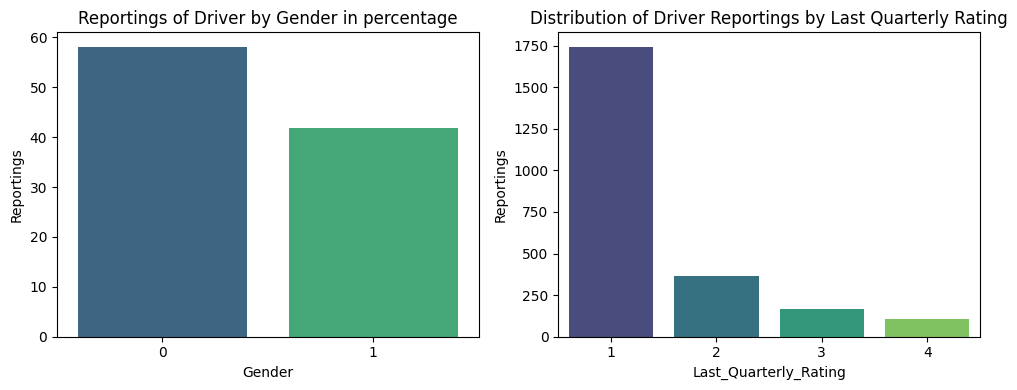

In [61]:
plt.figure(figsize=(10, 4))

# Plot 1: Reportings of Driver by Gender in percentage
plt.subplot(1, 2, 1)
grouped_gender = (agg_df.groupby('Gender')['Reportings'].sum() / agg_df['Reportings'].sum() * 100).round(2).reset_index()
sns.barplot(x='Gender', y='Reportings', data=grouped_gender, palette='viridis')
plt.title('Reportings of Driver by Gender in percentage', fontsize=12)

# Plot 2: Distribution of Driver Reportings by Last Quarterly Rating
plt.subplot(1, 2, 2)
grouped_quarterly_ratings = agg_df.groupby(['Last_Quarterly_Rating'])['Reportings'].count().reset_index()
sns.barplot(data=grouped_quarterly_ratings, x='Last_Quarterly_Rating', y='Reportings', palette='viridis')
plt.title('Distribution of Driver Reportings by Last Quarterly Rating', fontsize=12)

plt.tight_layout()
plt.show()

**Insights:**

*  Male drivers report 58.12%, while female drivers report 41.88%.
*  Highest reporting are from drivers with Quarterly Rating of 1.

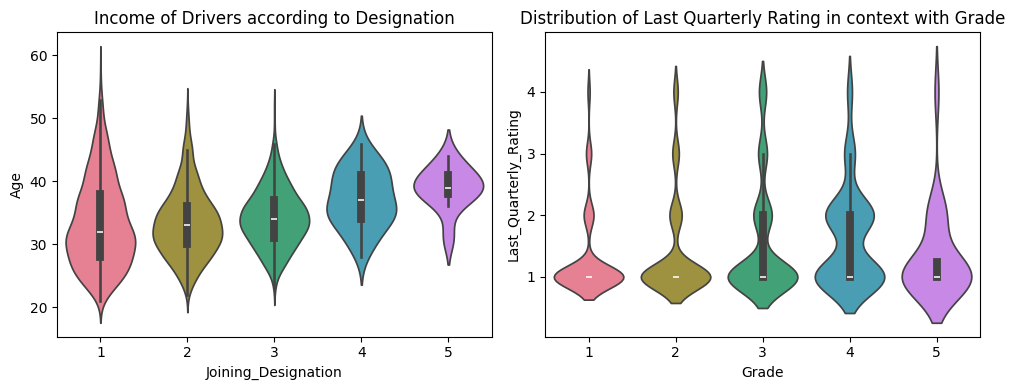

In [62]:
plt.figure(figsize=(10,4))

# Plot 1: Income of Drivers according to Designation
plt.subplot(1,2,1)
sns.violinplot(y=agg_df.Age,x=agg_df['Joining_Designation'],palette='husl')
plt.title('Income of Drivers according to Designation', fontsize=12)

# Plot 2: Distribution of Last Quarterly Rating in context with Grade
plt.subplot(1,2,2)
sns.violinplot(x=agg_df['Grade'],y=agg_df["Last_Quarterly_Rating"],palette='husl')
plt.title('Distribution of Last Quarterly Rating in context with Grade', fontsize=12)

plt.tight_layout()
plt.show()

**Insights:**

*  Age and Designation: Higher designations generally correlate with higher ages.
*  LastQuarterly Rating and Grade: Higher grades show greater variability in last quarterly ratings.

In [63]:
# Group data by different categories and calculate the sum of 'Income'

grouped_gender = agg_df.groupby('Gender')['Income'].sum().reset_index()
grouped_education = agg_df.groupby('Education_Level')['Income'].sum().reset_index()
grouped_grade = agg_df.groupby('Grade')['Income'].sum().reset_index()
grouped_desig = agg_df.groupby('Joining_Designation')['Income'].sum().reset_index()
grouped_LQR = agg_df.groupby('Last_Quarterly_Rating')['Income'].sum().reset_index()
grouped_target = agg_df.groupby('target')['Income'].sum().reset_index()
grouped_raise = agg_df.groupby('Raise')['Income'].sum().reset_index()
grouped_RI = agg_df.groupby('Rating_Increased')['Income'].sum().reset_index()

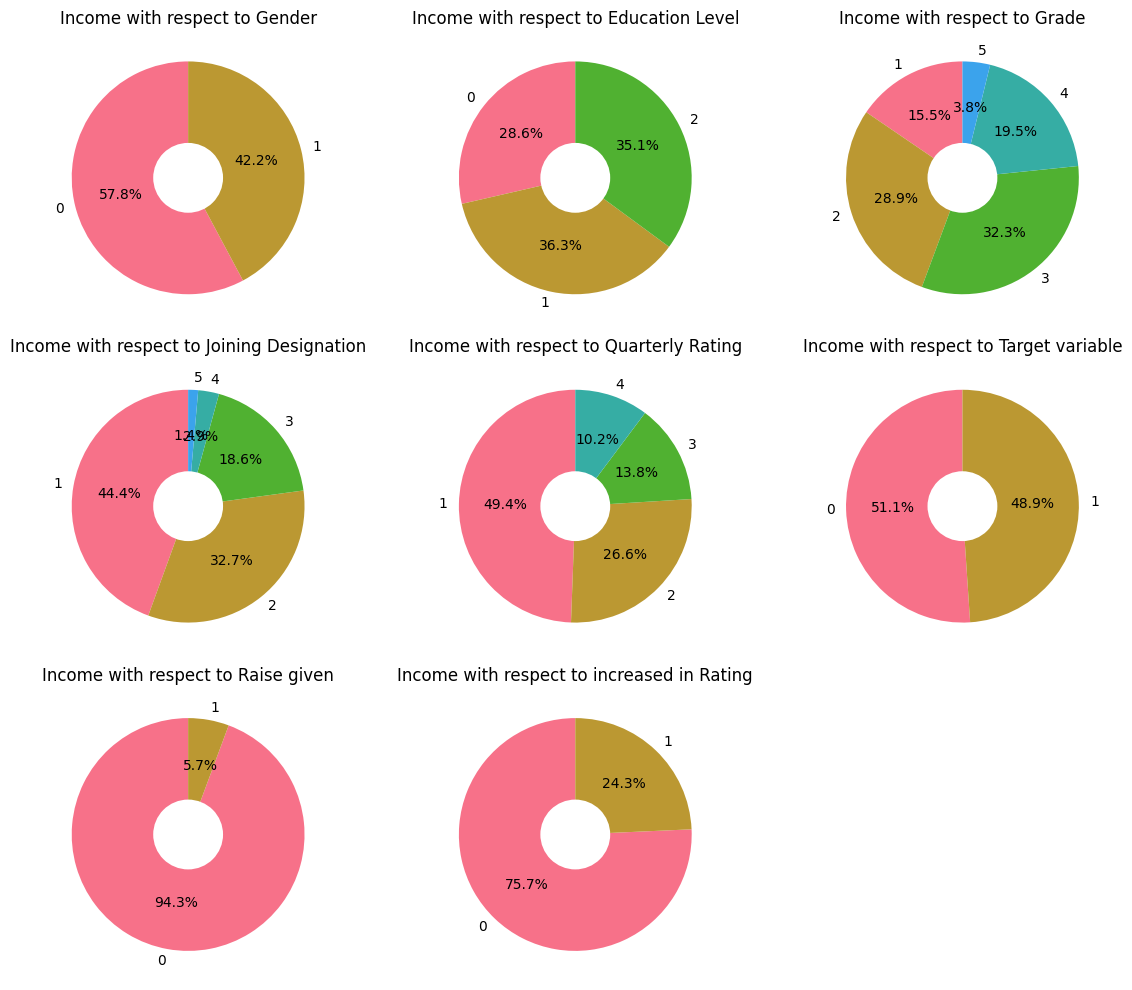

In [64]:
# Create the subplots
plt.figure(figsize=(12, 10))

# List of grouped data, labels, and titles
grouped_data = [
    (grouped_gender, 'Gender', 'Income with respect to Gender'),
    (grouped_education, 'Education_Level', 'Income with respect to Education Level'),
    (grouped_grade, 'Grade', 'Income with respect to Grade'),
    (grouped_desig, 'Joining_Designation', 'Income with respect to Joining Designation'),
    (grouped_LQR, 'Last_Quarterly_Rating', 'Income with respect to Quarterly Rating'),
    (grouped_target, 'target', 'Income with respect to Target variable'),
    (grouped_raise, 'Raise', 'Income with respect to Raise given'),
    (grouped_RI, 'Rating_Increased', 'Income with respect to increased in Rating')
]

# Plot each pie chart in the appropriate subplot
for i, (data, label, title) in enumerate(grouped_data):
    plt.subplot(3, 3, i+1)
    plt.pie(data['Income'], labels=data[label], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('husl'))
    hole = plt.Circle((0, 0), 0.3, facecolor='white')
    plt.gcf().gca().add_artist(hole)
    plt.title(title)

plt.tight_layout()
plt.show()

**Insights:**

*  Gender and Income: Higher income percentage seen in males (57.8%).
*  Education Level: Education levels 1 (36.3%) and 2 (35.1%) contributes most to higher income.
*  Grade: Grade 3 has the highest income proportion (32.3%).
*  Joining Designation: Designation 1 has the highest income share (44.4%).
*  Quarterly Rating: Rating 1 has the largest income distribution (49.4%).
*  Target Variable: Income distribution is almost equally split (51.1% vs 48.9%).
*  Raise: The highest income group rarely receives raises, with only 5.7% occurrence.
*  Increase in Rating: Only 24.3% of income group has experienced increase in rating.

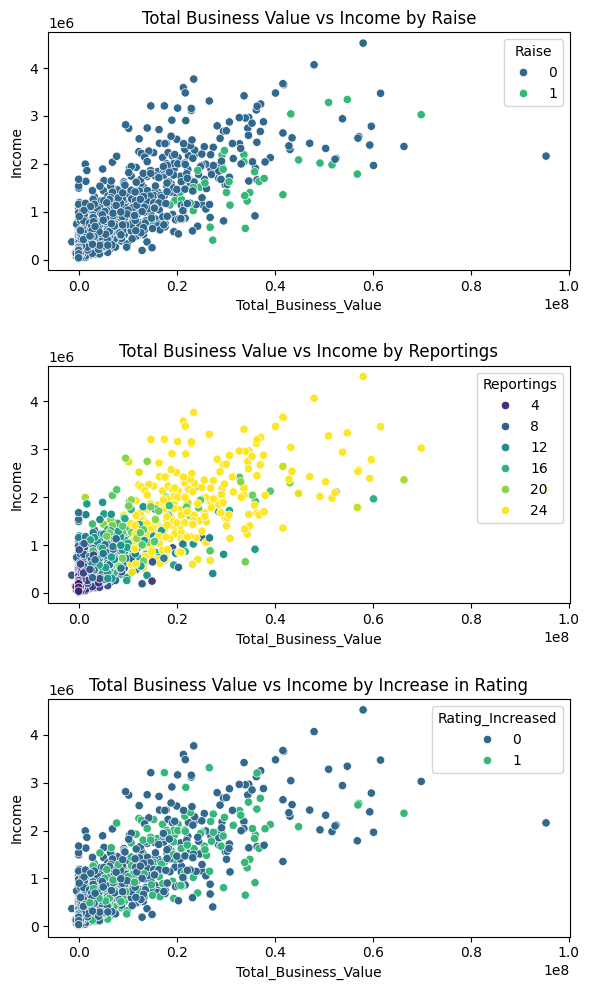

In [65]:
plt.figure(figsize=(6, 10))

# Scatter plot for Total Business Value vs Income, colored by Raise
plt.subplot(3, 1, 1)
sns.scatterplot(x=agg_df['Total_Business_Value'], y=agg_df.Income, hue=agg_df.Raise, palette='viridis')
plt.title('Total Business Value vs Income by Raise', fontsize=12)

# Scatter plot for Total Business Value vs Income, colored by Reportings
plt.subplot(3, 1, 2)
sns.scatterplot(x=agg_df['Total_Business_Value'], y=agg_df.Income, hue=agg_df.Reportings, palette='viridis')
plt.title('Total Business Value vs Income by Reportings', fontsize=12)

# Scatter plot for Total Business Value vs Income, colored by Rating Change
plt.subplot(3, 1, 3)
sns.scatterplot(x=agg_df['Total_Business_Value'], y=agg_df.Income, hue=agg_df.Rating_Increased, palette='viridis')
plt.title('Total Business Value vs Income by Increase in Rating', fontsize=12)

plt.tight_layout()
plt.show()

**Insights:**

*  Total Business Value vs Income by Raise: Income increases with business value, but those with raises (green) are less common.

*  Total Business Value vs Income by Reportings: Higher reportings (yellow) correlate with higher income and business value, showing strong engagement.

*  Total Business Value vs Income by Rating Change: Both negative (purple) and positive (yellow) rating changes occur across all income levels, indicating varied performance impacts.

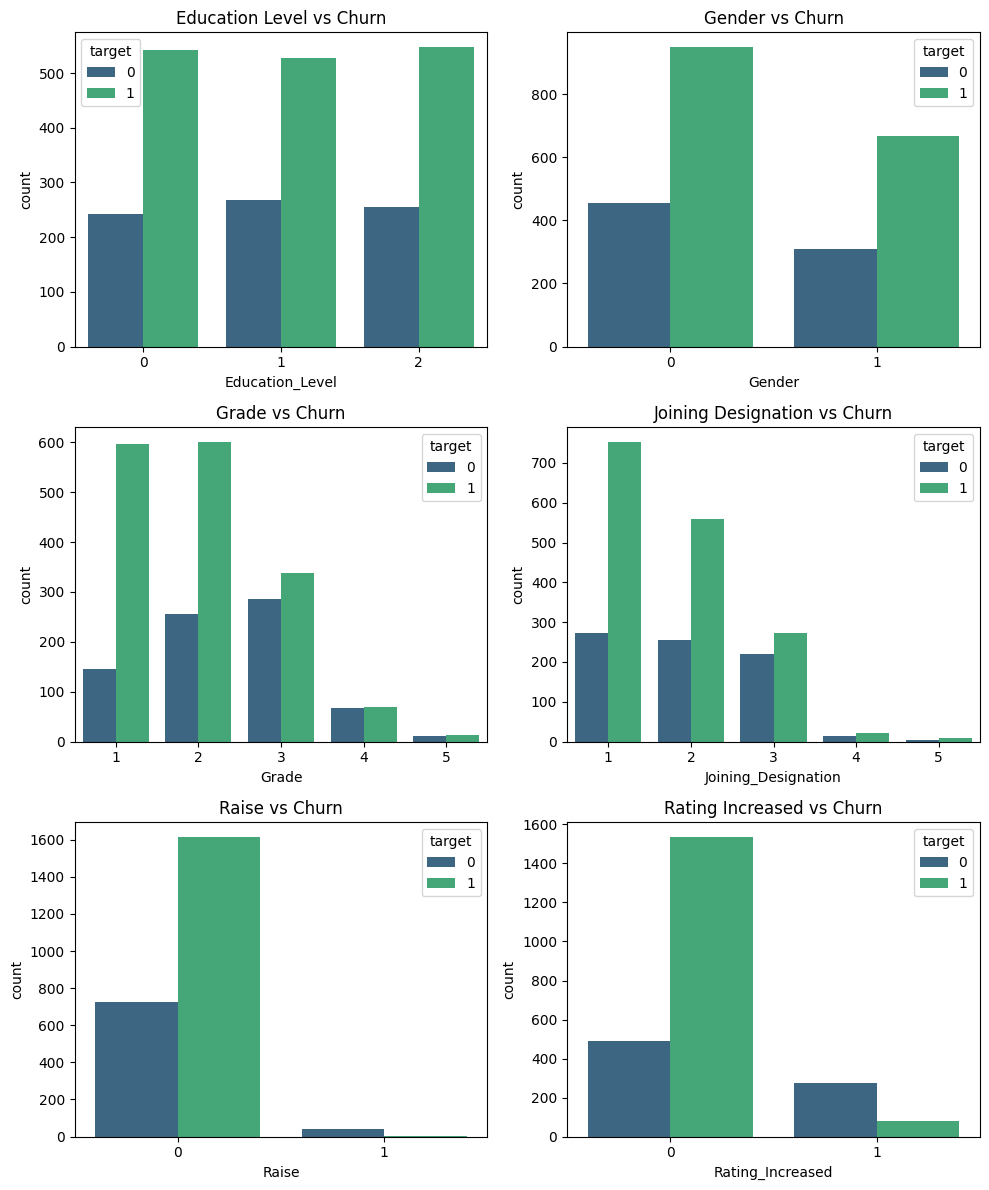

In [66]:
plt.figure(figsize=(10,12))

plt.subplot(3,2,1)
sns.countplot(data=agg_df, hue="target", x="Education_Level", palette='viridis')
plt.title("Education Level vs Churn", fontsize=12)

plt.subplot(3,2,2)
sns.countplot(data=agg_df, hue="target", x="Gender", palette='viridis')
plt.title("Gender vs Churn", fontsize=12)

plt.subplot(3,2,3)
sns.countplot(data=agg_df, hue="target", x="Grade", palette='viridis')
plt.title("Grade vs Churn", fontsize=12)

plt.subplot(3,2,4)
sns.countplot(data=agg_df, hue="target", x="Joining_Designation", palette='viridis')
plt.title("Joining Designation vs Churn", fontsize=12)

plt.subplot(3,2,5)
sns.countplot(data=agg_df, hue="target", x="Raise", palette='viridis')
plt.title("Raise vs Churn", fontsize=12)

plt.subplot(3,2,6)
sns.countplot(data=agg_df, hue="target", x="Rating_Increased", palette='viridis')
plt.title("Rating Increased vs Churn", fontsize=12)

plt.tight_layout()
plt.show()

**Insights:**

*  The proportion of Gender and education is more or less the same for both the employees who left the organization and those who did not leave.
*  The employees who have their Grade as 3 or more at the time of joining are less likely to leave the organization.
*  The employees whose Joining Designation is 3 or more at the time of joining are less likely to leave the organization.
*  The employees whose monthly salary has not increased are more likely to leave the organization.
*  The employees whose quarterly rating has increased are less likely to leave the organization.

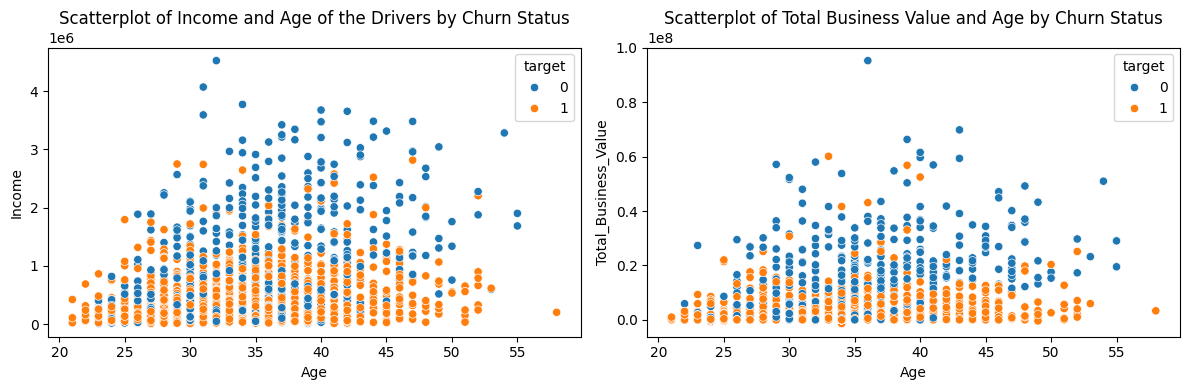

In [67]:
plt.figure(figsize=(12,4))

# Plot 1: Income of Drivers according to Age by Churn Status
plt.subplot(1,2,1)
sns.scatterplot(x=agg_df.Age,y=agg_df.Income,hue=agg_df.target)
plt.title('Scatterplot of Income and Age of the Drivers by Churn Status', fontsize=12)

# Plot 2: Total Business Value of Drivers according to Age by Churn Status
plt.subplot(1,2,2)
sns.scatterplot(x=agg_df.Age,y=agg_df['Total_Business_Value'],hue=agg_df.target)
plt.title('Scatterplot of Total Business Value and Age by Churn Status', fontsize=12)

plt.tight_layout()
plt.show()

**Insights:**

*  Income and Age: Non-churn drivers (target 0) have higher incomes, especially between ages 30-50; churn drivers earn less consistently.

*  Total Business Value and Age: Higher total business values are seen in non-churn drivers (target 0), mainly ages 30-45; churn drivers show lower values.

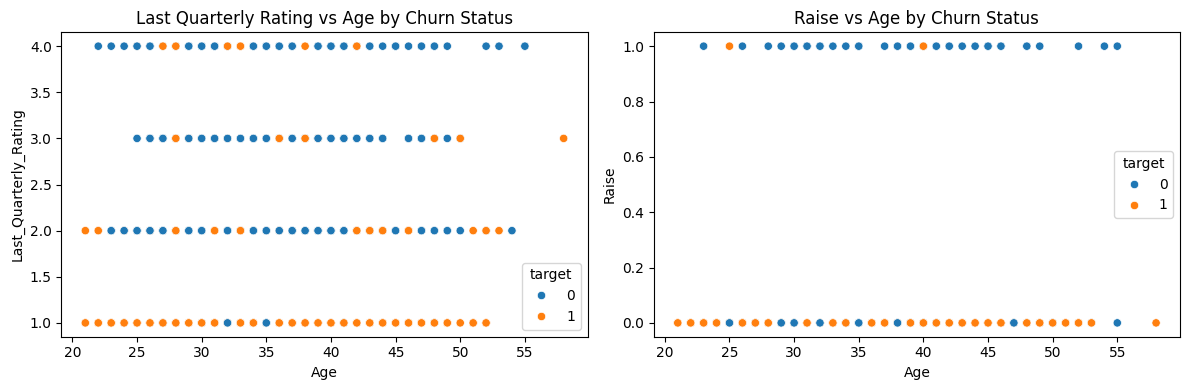

In [68]:
plt.figure(figsize=(12, 4))

# Plot 1: Last Quarterly Rating of Drivers according to Age by Churn Status
plt.subplot(1, 2, 1)
sns.scatterplot(x=agg_df.Age, y=agg_df['Last_Quarterly_Rating'], hue=agg_df.target)
plt.title('Last Quarterly Rating vs Age by Churn Status', fontsize=12)

# Plot 2: Raise of Drivers according to Age by Churn Status
plt.subplot(1, 2, 2)
sns.scatterplot(x=agg_df.Age, y=agg_df['Raise'], hue=agg_df.target)
plt.title('Raise vs Age by Churn Status', fontsize=12)

plt.tight_layout()
plt.show()

**Insights:**

*  Quarterly Rating vs Age: Churn is more common at the lowest rating (1) across all age groups, showing dissatisfaction leads to churn.

*  Raise vs Age: Churn is more frequent among those with no raise across all age groups, suggesting raises may reduce churn.

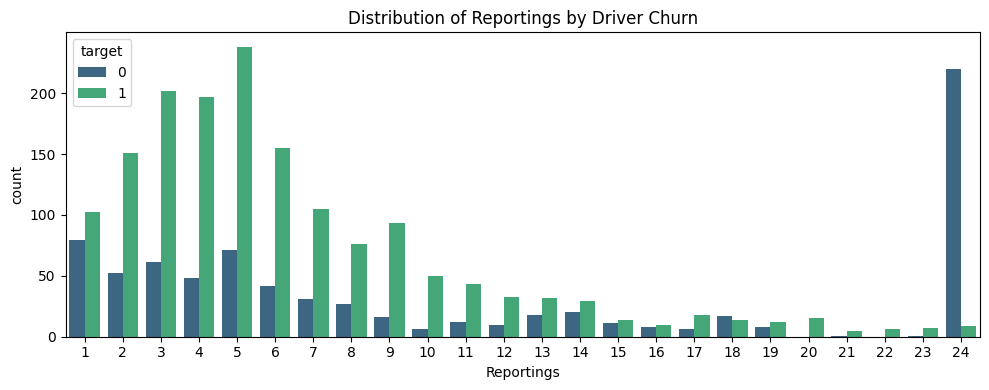

In [69]:
# Distribution of Reportings by Driver Churn

plt.figure(figsize=(10,4))
sns.countplot(x=agg_df.Reportings,hue=agg_df.target,palette='viridis')
plt.title('Distribution of Reportings by Driver Churn',fontsize=12)
plt.tight_layout()
plt.show()

**Insights:** Churners (target 1) peak around 5 reportings, while non-churners (target 0) spike at 24.

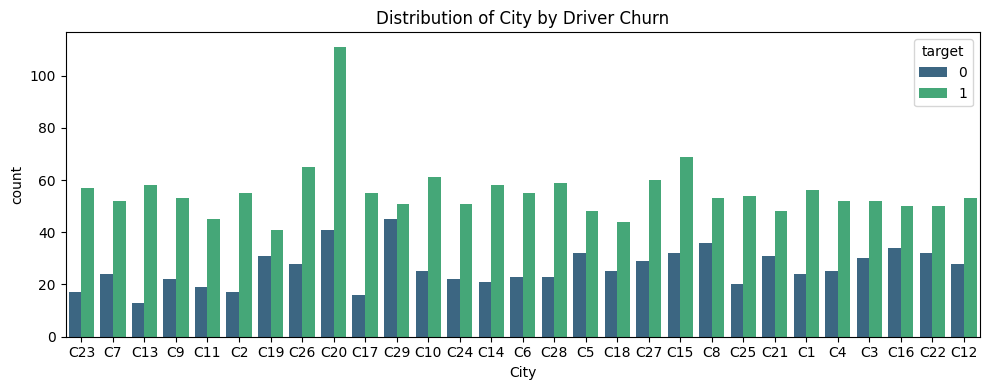

In [70]:
# Distribution of City by Driver Churn

plt.figure(figsize=(10,4))
sns.countplot(x=agg_df.City,hue=agg_df.target,palette='viridis')
plt.title('Distribution of City by Driver Churn',fontsize=12)
plt.tight_layout()
plt.show()

**Insights:** Cities C17, C20, and C13 show higher churn rates, while C29 and C19 have lower churn rates.

In [71]:
df_copy = agg_df.copy()

## Train-test split

In [72]:
# Define the feature set and the target variable

X = agg_df.drop(['Driver_ID','target'],axis=1) #'Driver_ID' is just an identifier and doesn't carry any predictive value for the model
y = agg_df['target']

In [73]:
X.columns

Index(['Reportings', 'Age', 'Gender', 'City', 'Education_Level', 'Grade',
       'Total_Business_Value', 'Income', 'Joining_Designation',
       'Last_Quarterly_Rating', 'Rating_Increased', 'Raise', 'Month', 'Year'],
      dtype='object')

In [74]:
from sklearn.model_selection import train_test_split

# Let's split the data into training, validation and testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (1904, 14)
Shape of X_test: (477, 14)
Shape of y_train: (1904,)
Shape of y_test: (477,)


## Target Encoding

In [75]:
X['City'].nunique()

29

**Note:** Categorical feature `City` has 29 unique values, so we'll opt for Target encoding.

In [76]:
from sklearn.preprocessing import TargetEncoder

# Step 1: Initialize the TargetEncoder
encoder = TargetEncoder(smooth="auto")

# Step 2: Fit the encoder on the training data and transform both training and validation data
X_train['City_TE'] = encoder.fit_transform(X_train[['City']], y_train)
X_test['City_TE'] = encoder.transform(X_test[['City']])

# Step 3: Drop the original 'City' column
X_train.drop('City', axis=1, inplace=True)
X_test.drop('City', axis=1, inplace=True)

In [77]:
X_train.head()

,Reportings,Age,Gender,Education_Level,Grade,Total_Business_Value,Income,Joining_Designation,Last_Quarterly_Rating,Rating_Increased,Raise,Month,Year,City_TE
457,2,28,0,0,3,0,175744,3,1,0,0,11,2020,0.767812
1739,5,34,0,0,2,466160,193095,2,1,0,0,11,2019,0.669879
1848,2,27,0,0,2,0,106210,1,1,0,0,2,2017,0.743451
1410,14,30,1,2,1,3489080,479276,1,2,1,0,11,2019,0.637130
829,24,47,0,0,3,22388420,2171616,1,3,0,0,7,2015,0.590985


In [78]:
X_test.head()

,Reportings,Age,Gender,Education_Level,Grade,Total_Business_Value,Income,Joining_Designation,Last_Quarterly_Rating,Rating_Increased,Raise,Month,Year,City_TE
1414,5,36,0,2,2,0,297405,2,1,0,0,11,2019,0.592327
1075,5,27,1,2,3,1445310,386845,1,1,0,0,4,2016,0.520326
1376,2,29,0,1,2,0,113970,2,1,0,0,11,2020,0.693293
2002,4,31,0,2,1,0,124496,1,1,0,0,10,2019,0.592327
1104,6,35,0,2,1,350000,238938,1,1,0,0,11,2019,0.520326


## Scaling Numeric Features

In [79]:
# Scaling Numeric Features using Standard scaler

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit and transform the training data, then transform the test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
print(X_train_scaled[:5,:])

[[-0.89285812 -0.96409437 -0.83303672 -1.24146766  0.94984581 -0.50796784
  -0.56655631  1.38644526 -0.53403045 -0.4264676  -0.13684514  1.14972542
   0.91087143  1.15385826]
 [-0.45183377  0.03470985 -0.83303672 -1.24146766 -0.10776028 -0.45757113
  -0.5389535   0.20215106 -0.53403045 -0.4264676  -0.13684514  1.14972542
   0.29258295 -0.09059935]
 [-0.89285812 -1.13056174 -0.83303672 -1.24146766 -0.10776028 -0.50796784
  -0.67717434 -0.98214315 -0.53403045 -0.4264676  -0.13684514 -1.73570146
  -0.94399403  0.84429063]
 [ 0.87123928 -0.63115963  1.20042727  1.2143811  -1.16536638 -0.13076224
  -0.08368299 -0.98214315  0.66501905  2.34484403 -0.13684514  1.14972542
   0.29258295 -0.50674603]
 [ 2.34132044  2.19878565 -0.83303672 -1.24146766  0.94984581  1.91245169
   2.60857292 -0.98214315  1.86406855 -0.4264676  -0.13684514 -0.13268653
  -2.18057101 -1.09311879]]


In [81]:
print(X_test_scaled[:5,:])

[[-0.45183377  0.36764458 -0.83303672  1.2143811  -0.10776028 -0.50796784
  -0.37301213  0.20215106 -0.53403045 -0.4264676  -0.13684514  1.14972542
   0.29258295 -1.07605902]
 [-0.45183377 -1.13056174  1.20042727  1.2143811   0.94984581 -0.3517149
  -0.23072668 -0.98214315 -0.53403045 -0.4264676  -0.13684514 -1.09449549
  -1.56228252 -1.99099128]
 [-0.89285812 -0.797627   -0.83303672 -0.01354328 -0.10776028 -0.50796784
  -0.66482936  0.20215106 -0.53403045 -0.4264676  -0.13684514  1.14972542
   0.91087143  0.20692702]
 [-0.59884189 -0.46469226 -0.83303672  1.2143811  -1.16536638 -0.50796784
  -0.64808409 -0.98214315 -0.53403045 -0.4264676  -0.13684514  0.82912243
   0.29258295 -1.07605902]
 [-0.30482565  0.20117721 -0.83303672  1.2143811  -1.16536638 -0.47012923
  -0.46602425 -0.98214315 -0.53403045 -0.4264676  -0.13684514  1.14972542
   0.29258295 -1.99099128]]


## Balancing Dataset using SMOTE

In [82]:
from imblearn.over_sampling import SMOTE

print("Before OverSampling")
print("Counts of label '1': {}".format(sum(y_train == 1)))
print("Counts of label '0': {} \n".format(sum(y_train == 0)))

sm = SMOTE(random_state = 42)
X_train_scaled_res, y_train_res = sm.fit_resample(X_train_scaled, y_train.ravel())

print("After OverSampling")
print("Counts of label '1': {}".format(sum(y_train_res == 1)))
print("Counts of label '0': {}".format(sum(y_train_res == 0)))

Before OverSampling
Counts of label '1': 1289
Counts of label '0': 615 

After OverSampling
Counts of label '1': 1289
Counts of label '0': 1289


# **Model building**

## Ensemble Learning: Bagging

### **Random Forest Classifier**

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

In [84]:
# Initialize and train a Random Forest classifier for the original data
random_forest_orig = RandomForestClassifier(oob_score=True, random_state=42)
random_forest_orig.fit(X_train_scaled, y_train)

# Retrieve the OOB score for the original data
oob_score_orig = random_forest_orig.oob_score_
print(f"The OOB score for original data is: {oob_score_orig:.4f}")

# Initialize and train a Random Forest classifier for the resampled data
random_forest_res = RandomForestClassifier(oob_score=True, random_state=42)
random_forest_res.fit(X_train_scaled_res, y_train_res)

# Retrieve the OOB score for the resampled data
oob_score_res = random_forest_res.oob_score_
print(f"The OOB score for resampled data is: {oob_score_res:.4f}")

The OOB score for original data is: 0.9223
The OOB score for resampled data is: 0.9430


**Insights:** OOB score is higher for the SMOTE-resampled dataset, suggesting improved model performance due to better class balance.

              precision    recall  f1-score   support

           0       0.91      0.87      0.89       150
           1       0.94      0.96      0.95       327

    accuracy                           0.93       477
   macro avg       0.93      0.92      0.92       477
weighted avg       0.93      0.93      0.93       477



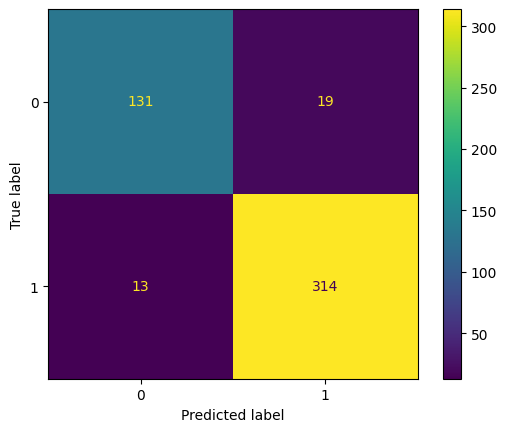

In [85]:
y_pred = random_forest_res.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=random_forest_res.classes_).plot()

**Random Forest Classifier**
* Out of all prediction, the measure for correctly predicted 0 is 91% and for 1 is 94% (Precision)
* Out of all actual 0, the measure for correctly predicted is 87% and for 1 is 96% (Recall)
* F1 Score of 0 is 89%
* F1 Score of 1 is 95%


#### Optimizing Random Forest Classifier

In [86]:
params = {
    "max_depth": [8, 10, 12],
    "n_estimators": [50, 100, 150],
    'min_samples_split': [3, 4, 5],
    'min_samples_leaf': [1, 2, 3]
}

In [87]:
start_time = time.time()
random_forest_1 = RandomForestClassifier(class_weight="balanced")
c = GridSearchCV(estimator=random_forest_1, param_grid=params, n_jobs=-1, cv=3, verbose=True, scoring='f1')

c.fit(X_train_scaled_res, y_train_res)

print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)
elapsed_time = time.time() - start_time

print("\nElapsed Time: ", elapsed_time)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Params:  {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 50}
Best Score:  0.938578290006156

Elapsed Time:  75.48748826980591


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       150
           1       0.95      0.96      0.95       327

    accuracy                           0.93       477
   macro avg       0.92      0.92      0.92       477
weighted avg       0.93      0.93      0.93       477



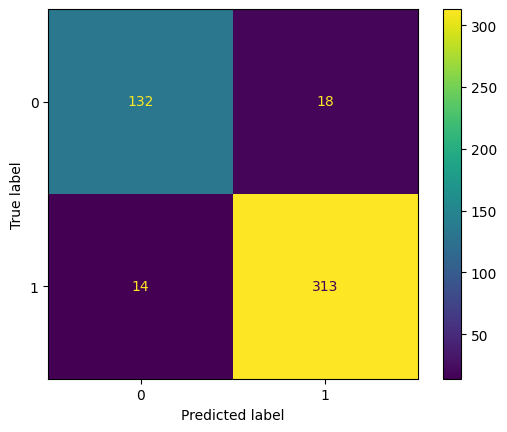

In [88]:
y_pred = c.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=c.classes_).plot()

**Random Forest Classifier with balanced class weight**
* Out of all prediction, the measure for correctly predicted 0 is 90% and for 1 is 95% (Precision)
* Out of all actual 0, the measure for correctly predicted is 88% and for 1 is 96% (Recall)
* F1 Score of 0 is 89%
* F1 Score of 1 is 95%

**Let's try Weighted Random Forest with Subsampling.**

In [89]:
start_time = time.time()
random_forest_2 = RandomForestClassifier(class_weight="balanced_subsample")
c = GridSearchCV(estimator=random_forest_2, param_grid=params, n_jobs=-1, cv=3, verbose=True, scoring='f1')

c.fit(X_train_scaled_res, y_train_res)

print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)
elapsed_time = time.time() - start_time

print("\nElapsed Time: ", elapsed_time)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Params:  {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best Score:  0.9382052244151137

Elapsed Time:  90.50792574882507


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       150
           1       0.95      0.95      0.95       327

    accuracy                           0.93       477
   macro avg       0.92      0.92      0.92       477
weighted avg       0.93      0.93      0.93       477



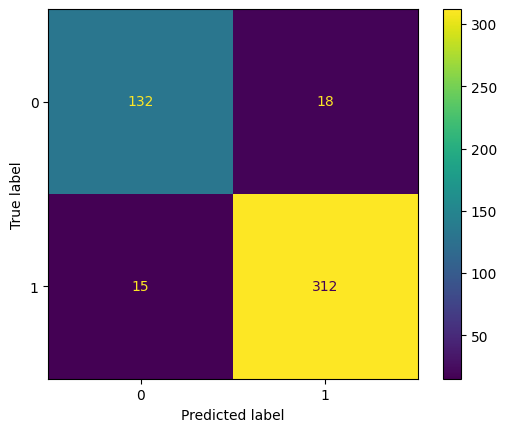

In [90]:
y_pred = c.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=c.classes_).plot()

**Random Forest Classifier with balanced_subsample class weight**
* Out of all prediction, the measure for correctly predicted 0 is 90% and for 1 is 95% (Precision)
* Out of all actual 0, the measure for correctly predicted is 88% and for 1 is 95% (Recall)
* F1 Score of 0 is 89%
* F1 Score of 1 is 95%

There is not much significant difference in the matrices observed for Bootstrapped Random Forest and Weighted Random Forest with Subsampling.

#### ROC-AUC Curve

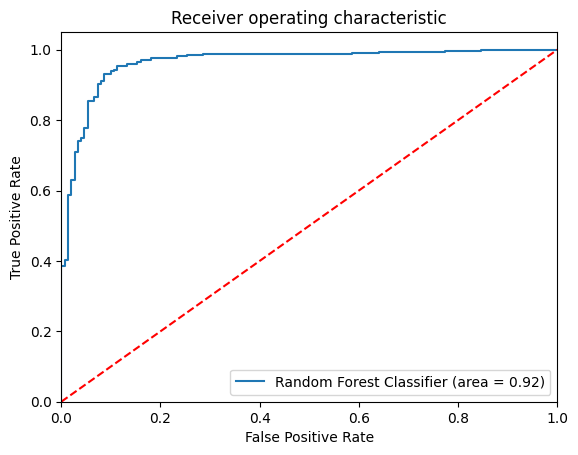

In [91]:
from sklearn.metrics import roc_auc_score, roc_curve

logit_roc_auc=roc_auc_score(y_test,y_pred)
fpr,tpr,thresholds=roc_curve(y_test,c.predict_proba(X_test_scaled)[:,1])
plt.figure()
plt.plot(fpr,tpr,label='Random Forest Classifier (area = %0.2f)' % logit_roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

## Ensemble Learning: Boosting

### **Gradient Boosting Classifier**

In [92]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [93]:
# Train Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train_scaled_res, y_train_res)
pred = gbc.predict(X_test_scaled)
accuracy = accuracy_score(y_test, pred)

print(f"Accuracy on processed data: {accuracy}")

Accuracy on processed data: 0.9266247379454927


**Optimizing Learning Rate**

In [94]:
# Define the learning rates to test
learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001]
best_accuracy = 0
best_learning_rate = 0

# Train a model for each learning rate and evaluate its accuracy

for lr in learning_rates:
    model = GradientBoostingClassifier(learning_rate=lr, random_state=42)
    model.fit(X_train_scaled_res, y_train_res)
    accuracy = accuracy_score(y_test, model.predict(X_test_scaled))
    print(lr, " : ", accuracy)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_learning_rate = lr

print(f"The best learning rate is: {best_learning_rate} with an accuracy of: {best_accuracy}")

0.1  :  0.9266247379454927
0.05  :  0.9245283018867925
0.01  :  0.9140461215932913
0.005  :  0.9161425576519916
0.001  :  0.9161425576519916
The best learning rate is: 0.1 with an accuracy of: 0.9266247379454927


**Boosting Max Depth**

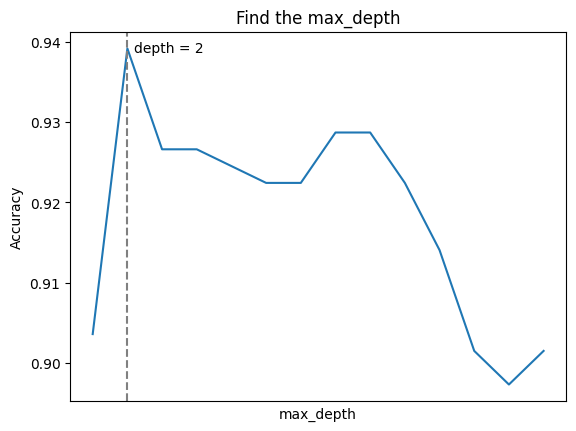

In [95]:
acc = []
best_depth = 0
best_acc = 0

# Train a model for each depth and evaluate its accuracy
for d in range(1,15):
    model = GradientBoostingClassifier(max_depth= d , random_state=42)
    model.fit(X_train_scaled_res, y_train_res)
    accuracy = accuracy_score(y_test, model.predict(X_test_scaled))
    acc.append(accuracy)

    if accuracy > best_acc:
      best_acc = accuracy
      best_depth = d

# Create the line plot
sns.lineplot(x=range(1, 15), y=acc)

# Remove x-ticks
plt.xticks([])

# Add x-axis label
plt.title("Find the max_depth")
plt.xlabel('max_depth')
plt.ylabel('Accuracy')

# Annotate the line at x = best_depth
highest_acc = acc[best_depth - 1]  # Adjusting for zero-based indexing
plt.axvline(x=best_depth, color='gray', linestyle='--')
plt.text(best_depth + 0.2, highest_acc, f"depth = {best_depth}", verticalalignment='center')

# Show the plot
plt.show()

#### Optimizing Gradient Boosting Classifier

In [100]:
params = {
    "max_depth": [2,3,4],
    "loss": ["log_loss", "exponential"],
    "subsample": [0.1, 0.2, 0.5, 0.8, 1],
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators": [50,100,150,200]
}

Fitting 3 folds for each of 360 candidates, totalling 1080 fits
Best Params:  {'learning_rate': 0.2, 'loss': 'log_loss', 'max_depth': 4, 'n_estimators': 50, 'subsample': 1}
Best Score:  0.9422110620786746

 Elapsed Time:  418.79997968673706
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       150
           1       0.95      0.94      0.95       327

    accuracy                           0.93       477
   macro avg       0.91      0.92      0.92       477
weighted avg       0.93      0.93      0.93       477



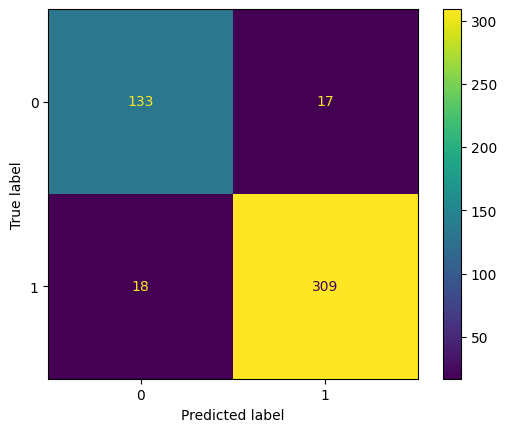

In [102]:
gbdt = GradientBoostingClassifier()
start_time = time.time()
c = GridSearchCV(estimator=gbdt, cv=3, n_jobs=-1, verbose=True, param_grid=params)

c.fit(X_train_scaled_res, y_train_res)
print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)

elapsed_time = time.time() - start_time
print("\n Elapsed Time: ", elapsed_time)

y_pred = c.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=c.classes_).plot()

**Gradient Boosting Classifier Metrics**
* Out of all prediction, the measure for correctly predicted 0 is 88% and for 1 is 95% (Precision)
* Out of all actual 0, the measure for correctly predicted is 89% and for 1 is 94% (Recall)
* F1 Score of 0 is 88%
* F1 Score of 1 is 95%

#### ROC-AUC Curve

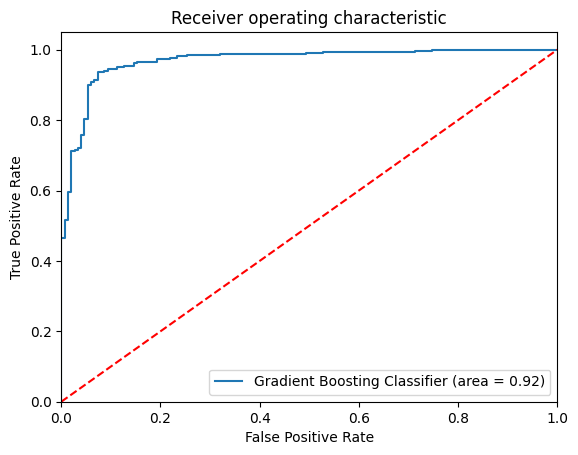

In [103]:
logit_roc_auc=roc_auc_score(y_test,y_pred)
fpr,tpr,thresholds=roc_curve(y_test,c.predict_proba(X_test_scaled)[:,1])
plt.figure()
plt.plot(fpr,tpr,label='Gradient Boosting Classifier (area = %0.2f)' % logit_roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

### **XGBoost Classifier**

XGBoost Classifier Score:  0.9329140461215933

               precision    recall  f1-score   support

           0       0.90      0.89      0.89       150
           1       0.95      0.95      0.95       327

    accuracy                           0.93       477
   macro avg       0.92      0.92      0.92       477
weighted avg       0.93      0.93      0.93       477



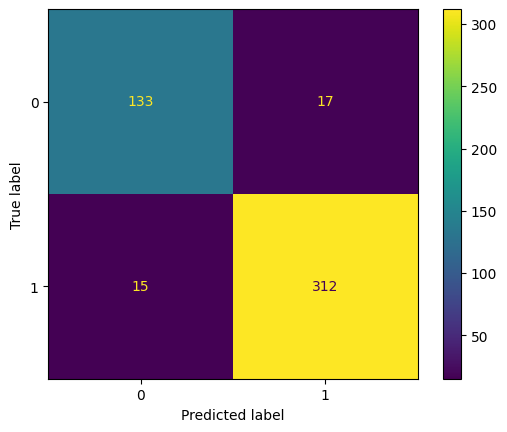

In [104]:
from xgboost import XGBClassifier

model = XGBClassifier(class_weight = "balanced")

model.fit(X_train_scaled_res, y_train_res)

y_pred = model.predict(X_test_scaled)
print("XGBoost Classifier Score: ", model.score(X_test_scaled, y_test))
print("\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot()

**XGBoost Classifier with balanced class weight**
* Out of all prediction, the measure for correctly predicted 0 is 90% and for 1 is 95% (Precision)
* Out of all actual 0, the measure for correctly predicted is 89% and for 1 is 95% (Recall)
* F1 Score of 0 is 89%
* F1 Score of 1 is 95%

#### ROC-AUC Curve

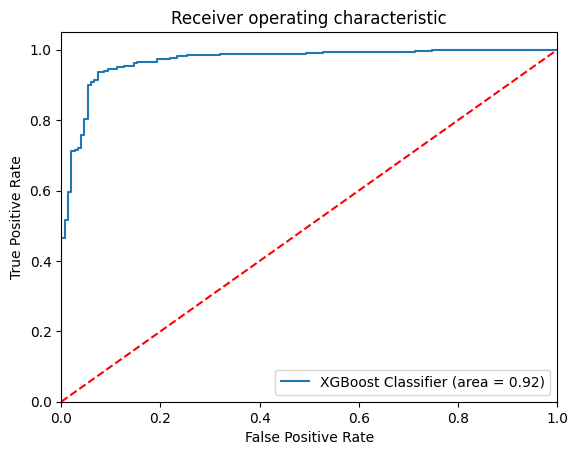

In [105]:
logit_roc_auc=roc_auc_score(y_test,y_pred)
fpr,tpr,thresholds=roc_curve(y_test,c.predict_proba(X_test_scaled)[:,1])
plt.figure()
plt.plot(fpr,tpr,label='XGBoost Classifier (area = %0.2f)' % logit_roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

## **Final Result Evaluation**

- We observe that we are getting almost same recall and precision values from all techniques.
- Higher precision means that an algorithm returns more relevant results than irrelevant ones, and high recall means that an algorithm returns most of the relevant results (whether or not irrelevant ones are also returned).


- **We observe that Random Forest with SMOTE outperforms rest of the models and has higher recall and precision values.**
    - The Random Forest method out of all predicted 0 the measure of correctly predicted is 90%, and for 1 it is 95% (Precision).
    - The Random Forest method out of all actual 0 the measure of correctly predicted is 88%, and for 1 it is 96% (Recall).
    - The ROC-AUC curve area for Random Forest Classifier is 0.92


- **Gradient Boosting Classifier Result**
    - Out of all prediction, the measure for correctly predicted 0 is 88% and for 1 is 95% (Precision)
    - Out of all actual 0, the measure for correctly predicted is 89% and for 1 is 94% (Recall)
    - The ROC-AUC curve area for Gradient Boosting Decision Tree Classifier is 0.92


- **XGBoost Classifier Result**
    - Out of all prediction, the measure for correctly predicted 0 is 90% and for 1 is 95% (Precision)
    - Out of all actual 0, the measure for correctly predicted is 89% and for 1 is 95% (Recall)
    - The ROC-AUC curve area for XGBoost Classifier is 0.92

## Feature Importance of the best model

**Random Forest Classifier outperforms the rest of the modal.**

**Best parameters**

Best Params:  {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 50}

In [106]:
rf = RandomForestClassifier(max_depth=12, n_estimators=50, class_weight="balanced", min_samples_leaf=1, min_samples_split=4)

rf.fit(X_train_scaled_res, y_train_res)
print("Score of RandomForestClassifier: ", rf.score(X_test_scaled, y_test))

Score of RandomForestClassifier:  0.9287211740041929


In [107]:
importances = rf.feature_importances_
importances

array([0.15693705, 0.03611817, 0.00627828, 0.01139211, 0.02466765,
       0.1166057 , 0.06467621, 0.03299642, 0.11917597, 0.06764738,
       0.00249836, 0.11472728, 0.21265992, 0.03361948])

In [108]:
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

<Figure size 1500x700 with 0 Axes>

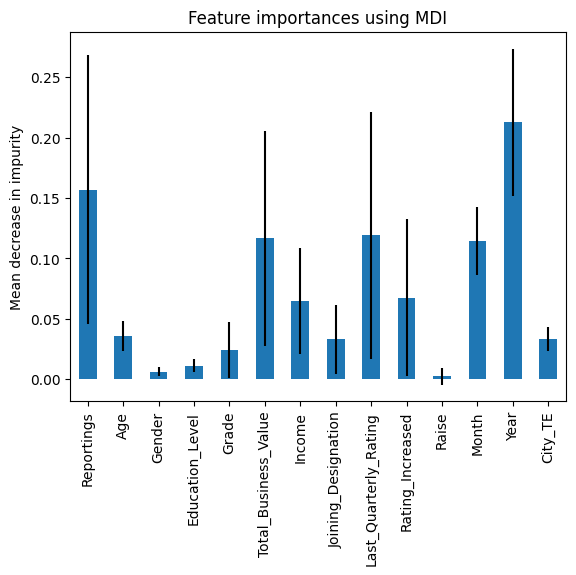

In [109]:
feature_importances = pd.Series(importances, X_train.columns)

plt.figure(figsize=(15,7))
fig, ax = plt.subplots()
feature_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")

plt.show()

Year, Reportings, Last_Quarterly_Rating, Total_Business_Value, Month, Rating_Increased and Income are the most important features.

# Insights and Recommendations

## **Insights**

*  **Driver Churn Rate:** 68% churn rate suggests a need for retention strategies targeting driver satisfaction and engagement.
*  **Age Group Engagement:** Drivers aged 25-40 show maximum engagement; retention strategies could focus on this age group.
*  **Income Distribution:** Skewed income distribution suggests potential wage inequality; addressing this may reduce churn.
*  **City-Based Churn:** Cities C17, C20, and C13 show higher churn rates, indicating a need for city-specific interventions.
*  **Tenure and Retention:** Most drivers leave within 2-6 months, peaking at 5 months, suggesting a critical period for retention efforts.
*  **Education and Churn:** Education levels have little impact on churn, suggesting focus elsewhere for retention strategies.
*  **Raise Impact:** Drivers without raises are more likely to churn, highlighting the importance of performance-based incentives.
*  **Quarterly Ratings:** Low quarterly ratings correlate with higher churn, indicating a need for performance improvement programs.
*  **Income vs. Churn:** Higher income generally correlates with lower churn, especially among older drivers.
*  **Reporting Activity:** Increased reporting correlates with lower churn, suggesting that driver engagement metrics are critical.
*  **Model Score:**  The Random Forest Classifier attains the Recall score of 96% for the driver who left the company, which indicates that model is performing a good job.

## **Recommendations**

*  **Retention Programs:** Focus on drivers aged 25-40 to enhance engagement and reduce churn.
*  **Wage Equality:** Implement policies to balance income distribution and address wage disparities.
*  **City-Specific Strategies:** Develop targeted retention strategies for high-churn cities like C17, C20, and C13.
*  **Critical Retention Period:** Implement retention efforts during the first 2-6 months of tenure to reduce early churn.
*  **Performance-Based Incentives:** Introduce regular performance-based raises to incentivize long-term retention.
*  **Performance Improvement Plans:** Address low quarterly ratings with personalized coaching and support programs.
*  **Driver Engagement:** Boost engagement through regular reporting and feedback mechanisms.
*  **Focus on Income Growth:** Design income growth pathways for older drivers to reduce churn.
*  **Education on Reporting Benefits:** Educate drivers on the benefits of active reporting to encourage consistent engagement.
*  **Customer Feedback Improvement:** Investigate the reasons behind low customer ratings for drivers and implement strategies to enhance driver performance and satisfaction.